In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [7]:
img = cv2.imread('UTS.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

In [8]:
lower_blue, upper_blue = np.array([100, 50, 50]), np.array([130, 255, 255])
lower_red1, upper_red1 = np.array([0, 50, 50]), np.array([10, 255, 255])
lower_red2, upper_red2 = np.array([170, 50, 50]), np.array([180, 255, 255])
lower_green, upper_green = np.array([35, 50, 50]), np.array([85, 255, 255])

In [12]:
mask_b = cv2.inRange(img_hsv, lower_blue, upper_blue)
mask_g = cv2.inRange(img_hsv, lower_green, upper_green)
mask_r = cv2.bitwise_or(cv2.inRange(img_hsv, lower_red1, upper_red1), cv2.inRange(img_hsv, lower_red2, upper_red2))

res_b = cv2.bitwise_or(img_rgb, img_rgb, mask=cv2.bitwise_not(mask_b))
res_r = cv2.bitwise_or(img_rgb, img_rgb, mask=cv2.bitwise_not(mask_r))
res_g = cv2.bitwise_or(img_rgb, img_rgb, mask=cv2.bitwise_not(mask_g))

In [13]:
res_b[mask_b > 0] = [255, 255, 255]
res_r[mask_r > 0] = [255, 255, 255]
res_g[mask_g > 0] = [255, 255, 255]

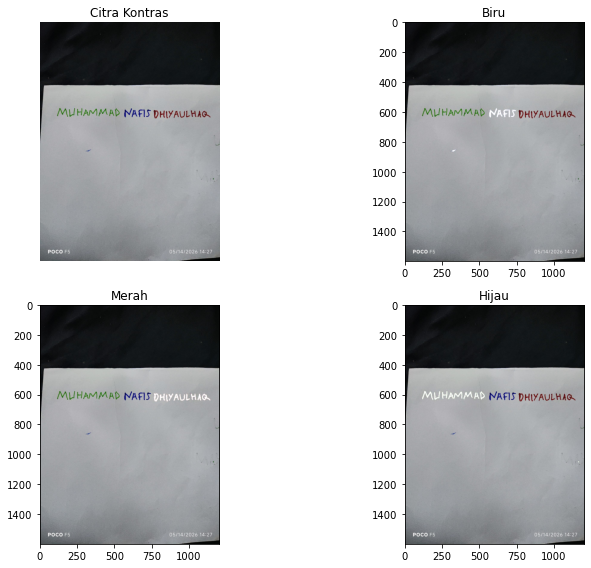

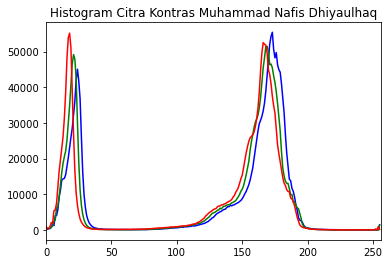

In [32]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title('Citra Kontras')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(res_b)
plt.title('Biru')
plt.axis('on')

plt.subplot(2, 2, 3)
plt.imshow(res_r)
plt.title('Merah')
plt.axis('on')

plt.subplot(2, 2, 4)
plt.imshow(res_g)
plt.title('Hijau')
plt.axis('on')

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
colors = ('b', 'g', 'r')
for i, col in enumerate(colors):
    hist = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(hist, color=col)
plt.title('Histogram Citra Kontras Muhammad Nafis Dhiyaulhaq')
plt.xlim([0, 256])
plt.show()

In [26]:
lower_blue = np.array([100, 50, 50])
upper_blue = np.array([130, 255, 255])

lower_red1 = np.array([0, 50, 50])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 50, 50])
upper_red2 = np.array([180, 255, 255])

lower_green = np.array([35, 50, 50])
upper_green = np.array([85, 255, 255])

In [27]:
mask_b = cv2.inRange(img_hsv, lower_blue, upper_blue)

mask_r1 = cv2.inRange(img_hsv, lower_red1, upper_red1)
mask_r2 = cv2.inRange(img_hsv, lower_red2, upper_red2)

mask_r = cv2.bitwise_or(mask_r1, mask_r2)

mask_g = cv2.inRange(img_hsv, lower_green, upper_green)

In [28]:
kernel = np.ones((3,3), np.uint8)

mask_b = cv2.morphologyEx(mask_b, cv2.MORPH_CLOSE, kernel)
mask_r = cv2.morphologyEx(mask_r, cv2.MORPH_CLOSE, kernel)
mask_g = cv2.morphologyEx(mask_g, cv2.MORPH_CLOSE, kernel)

In [29]:
mask_none = np.zeros_like(mask_b)
mask_blue = mask_b
mask_blue_red = cv2.bitwise_or(mask_b, mask_r)
mask_all = cv2.bitwise_or(mask_blue_red, mask_g)

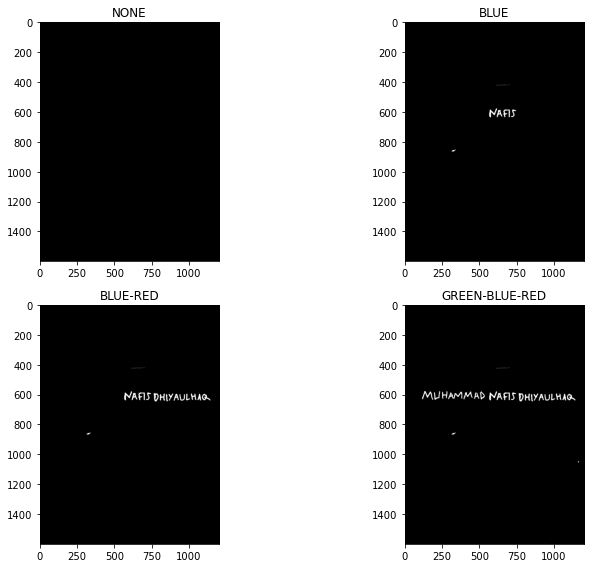

In [30]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(mask_none, cmap='gray')
plt.title('NONE')
plt.axis('on')

plt.subplot(2,2,2)
plt.imshow(mask_blue, cmap='gray')
plt.title('BLUE')
plt.axis('on')

plt.subplot(2,2,3)
plt.imshow(mask_blue_red, cmap='gray')
plt.title('BLUE-RED')
plt.axis('on')

plt.subplot(2,2,4)
plt.imshow(mask_all, cmap='gray')
plt.title('GREEN-BLUE-RED')
plt.axis('on')

plt.tight_layout()
plt.show()

In [33]:
img = cv2.imread('OPEX.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [36]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

bright = cv2.convertScaleAbs(gray, alpha=1.0, beta=60)
contrast = cv2.convertScaleAbs(gray, alpha=2.0, beta=0)
bright_contrast = cv2.convertScaleAbs(gray, alpha=2.0, beta=60)

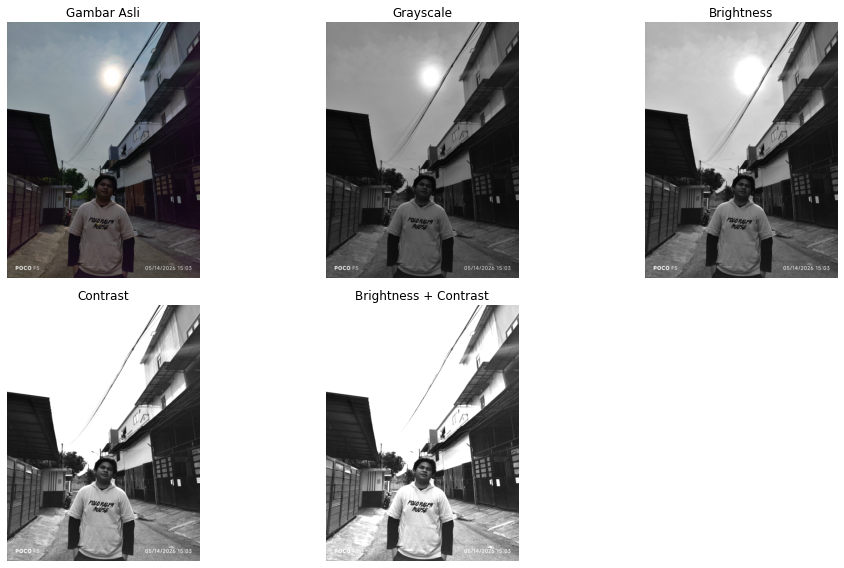

In [37]:
plt.figure(figsize=(14,8))

plt.subplot(2,3,1)
plt.imshow(img_rgb)
plt.title('Gambar Asli')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(bright, cmap='gray')
plt.title('Brightness')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(contrast, cmap='gray')
plt.title('Contrast')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(bright_contrast, cmap='gray')
plt.title('Brightness + Contrast')
plt.axis('off')

plt.tight_layout()
plt.show()